# ArXiv Abfragen

> arXiv is a project by the Cornell University Library that provides open access to 1,000,000+ articles in Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, and Statistics.

Wir benutzen [arXiv.org](https://arxiv.org/) hier als Datenlieferantin. Es bietet ein stabiles API, wofür es einen einfach zu benutzenden Python-Wrapper gibt: [arxiv.py](lukasschwab.me/arxiv.py). Das Ziel soll einerseits sein, eine sauber gegliederte Datenverarbeitungspipeline zu entwickeln, die das Resultat einer arxiv Abfrage in einen Pandas DataFrame abfüllt, und andererseits sollen Funktionen für explorative Analysen und Visualisierungen bereitgestellt werden.  

## Lernziele

Die Studierenden können

- komplexe Daten via API aus dem Internet zu beziehen.
- komplexe Daten in generische Datentypen (`dict`, `list`, `str`, `int`, `float`, `datetime`) zu transformieren.
- solche Daten nach gewissen Kriterien filtern und in einen [Pandas](https://pandas.pydata.org/) [DataFrame](https://pandas.pydata.org/docs/reference/frame.html) abzufüllen.
- explorative Analysen mithilfe von [Pandas](https://pandas.pydata.org/) durchführen.
- statistische Visualisierungen der Daten mit [Seaborn](https://seaborn.pydata.org/) erstellen.

## Voraussetzungen

Folgende Packages müssen mindestens installiert sein:

```shell
pip install arxiv pandas seaborn pipe
```

## Eine erste arXiv Abfrage

In der Dokumentation von [`arxiv`](lukasschwab.me/arxiv.py/) wird unter "Usage" beschrieben, wie Abfragen mithilfe eines `arxiv.Search` Objekts getätigt werden:

In [1]:
import arxiv

client = arxiv.Client()
search = arxiv.Search(
    query="quantum", max_results=10, sort_by=arxiv.SortCriterion.SubmittedDate
)

for result in client.results(search):
    print(result.title)

QwaveMPS: An efficient open-source Python package for simulating non-Markovian waveguide-QED using matrix product states
Hubble-Scale Tachyonic Shocks from Low-Scale Inflation -- A New Gravitational-Wave Window on Inflation
Radial oscillations of pulsating neutron stars: The UCIa equation-of-state case
Deformed Heisenberg algebra and its Hilbert space representations
Entanglement in the Dicke subspace
Steady state coherence in a qubit is incompatible with a quantum map
Timelike bounce hypersurfaces in charged null dust collapse
Quantitative local recovery of Kerr-de Sitter parameters from high-frequency equatorial quasinormal modes
Microscopic Rydberg electron orbit manipulation with optical tweezers
Meta-Learning for GPU-Accelerated Quantum Many-Body Problems


Schauen wir etwas genauer hin:

In [2]:
type(client.results(search))

itertools.islice

Die Resultate der Abfrage werden also `generator` zurückgegeben. Wir packen mal alle Resultate in eine Liste

In [3]:
results = list(client.results(search))
len(results)

10

Von den 10 Resultaten schauen wir uns das erste mal an:

In [4]:
r0 = results[0]
r0

arxiv.Result(entry_id='http://arxiv.org/abs/2602.15826v1', updated=datetime.datetime(2026, 2, 17, 18, 58, 55, tzinfo=datetime.timezone.utc), published=datetime.datetime(2026, 2, 17, 18, 58, 55, tzinfo=datetime.timezone.utc), title='QwaveMPS: An efficient open-source Python package for simulating non-Markovian waveguide-QED using matrix product states', authors=[arxiv.Result.Author('Sofia Arranz Regidor'), arxiv.Result.Author('Matthew Kozma'), arxiv.Result.Author('Stephen Hughes')], summary='QwaveMPS is an open-source Python library for simulating one-dimensional quantum many-body waveguide systems using matrix product states (MPS). It provides a user-friendly interface for constructing, evolving, and analyzing quantum states and operators, facilitating studies in quantum physics and quantum information with waveguide QED systems. This approach enables efficient, scalable simulations by focusing computational resources on the most relevant parts of the quantum system. Thus, one can stud

Das sieht etwas kompliziert aus. Also schauen wir, um welchen Datentyp es sich handelt:

In [5]:
type(r0)

arxiv.Result

Die Dokumentation von `arxiv` erzählt uns mehr über dieses Objekt; siehe unter [Usage > Result](http://lukasschwab.me/arxiv.py/index.html#usage) oder hier in der [API-Docu von `arxiv.Result`](http://lukasschwab.me/arxiv.py/index.html#Result).

Zum Beispiel können wir den Titel und die Autorenliste wie folgt herausziehen:

In [6]:
print("Titel:", r0.title)
print("Autoren:", r0.authors)

Titel: QwaveMPS: An efficient open-source Python package for simulating non-Markovian waveguide-QED using matrix product states
Autoren: [arxiv.Result.Author('Sofia Arranz Regidor'), arxiv.Result.Author('Matthew Kozma'), arxiv.Result.Author('Stephen Hughes')]


Der Titel scheint ein `str` zu sein, die Autoren sind aber wiederum Objekte, diesmal vom Typ `arxiv.Result.Author`. Die [API-Doc von `Author`](http://lukasschwab.me/arxiv.py/index.html#Result.Author) zeigt, welche Informationen ein `Author` zur Verfügung stellt - nur den Namen.

In [7]:
r0.authors[0].name, type(r0.authors[0].name)

('Sofia Arranz Regidor', str)

Als nächstes ist das Ziel, die Resultate in eine Form zu bringen, so dass sie einfach weiter verarbeitet werden können. Dazu eignen sich die primitiven Datentypen `int`, `float` und `str`, generische Datenstrukturen wie `list` und `dict`, sowie `datetime` Objekte für Zeitstempel. 

## Aufgabe 1: Transformation in generische Datentypen

Schreibe eine Funktion namens `result_to_dict()`, die ein `arxiv.Result` Objekt in ein `dict` transformiert. Dabei sollen folgende Angaben übernommen werden

- entry_id
- updated
- published
- title
- authors
- summary
- comment
- journal_ref
- doi
- primary_category
- categories

und zwar in Form einfacher Datentypen, d.h. es dürfen keine Objekte mehr vorkommen, die im `arxiv` Package definiert sind. Teste die Funktion mit dem Suchresultat `r0` von oben.

In [8]:
# Lösung:


def result_to_dict(result: arxiv.Result) -> dict:
    return {
        "entry_id": result.entry_id,  # A url http://arxiv.org/abs/{id}.
        "updated": result.updated,  # When the result was last updated.
        "published": result.published,  # When the result was originally published.
        "title": result.title,  # The title of the result.
        "authors": [
            a.name for a in result.authors
        ],  # The result's authors, as arxiv.Authors.
        "summary": result.summary,  # The result abstract.
        "comment": result.comment,  # The authors' comment if present.
        "journal_ref": result.journal_ref,  # A journal reference if present.
        "doi": result.doi,  # A URL for the resolved DOI to an external resource if present.
        "primary_category": result.primary_category,  # The result's primary arXiv category. See arXiv: Category Taxonomy.
        "categories": result.categories,  # All of the result's categories. See arXiv: Category Taxonomy.
        # 'links': result.links, # Up to three URLs associated with this result, as arxiv.Links.
        # 'pdf_url': result.pdf_url, # A URL for the result's PDF if present. Note: this URL also appears among result.links
    }

In [9]:
result_to_dict(r0)

{'entry_id': 'http://arxiv.org/abs/2602.15826v1',
 'updated': datetime.datetime(2026, 2, 17, 18, 58, 55, tzinfo=datetime.timezone.utc),
 'published': datetime.datetime(2026, 2, 17, 18, 58, 55, tzinfo=datetime.timezone.utc),
 'title': 'QwaveMPS: An efficient open-source Python package for simulating non-Markovian waveguide-QED using matrix product states',
 'authors': ['Sofia Arranz Regidor', 'Matthew Kozma', 'Stephen Hughes'],
 'summary': 'QwaveMPS is an open-source Python library for simulating one-dimensional quantum many-body waveguide systems using matrix product states (MPS). It provides a user-friendly interface for constructing, evolving, and analyzing quantum states and operators, facilitating studies in quantum physics and quantum information with waveguide QED systems. This approach enables efficient, scalable simulations by focusing computational resources on the most relevant parts of the quantum system. Thus, one can study a wide range of complex dynamical interactions, in

Soweit so gut. Das Summary kann noch etwas aufgeräumt werden und es wäre praktisch bereits ein paar weitere Infos aufzubereiten.

## Aufgabe 2: Zusätzliche Infos während Transformation zusammentragen

Entwickle die Funktion `result_to_dict()` so weiter, dass im Summary bereits Zeilenumbrüche (`'\n'`) durch Abstände (`' '`) ersetzt werden. Zudem sollen folgende Einträge ergänzt werden:

- `first_author`: Name der ersten Autor:in
- `n_authors`: Anzahl Autor:innen
- `title_length`: Länge des Titels (Anzahl Zeichen)
- `summary_length`: Länge des Summaries (Anzahl Zeichen)
- `n_categories`: Anzahl Kategorien

Wende schliesslich noch die Methode `.replace(tzinfo=None)` auf die beiden `datetime`-Objekte `Result.updated` und `Result.updated` an, um die Zeitzoneninformation zu entfernen, die später bei der Analyse nur stört.

Teste die Funktion wieder mit dem Suchresultat `r0` von oben.

In [10]:
# Lösung:


def result_to_dict(result: arxiv.Result) -> dict:
    summary = result.summary.replace("\n", " ")
    authors = [a.name for a in result.authors]
    return {
        "entry_id": result.entry_id,
        "updated": result.updated.replace(tzinfo=None),
        "published": result.published.replace(tzinfo=None),
        "title": result.title,
        "title_length": len(result.title),
        "authors": authors,
        "first_author": authors[0] if len(authors) > 0 else None,
        "n_authors": len(authors),
        "summary": summary,
        "summary_length": len(summary),
        "comment": result.comment,
        "journal_ref": result.journal_ref,
        "doi": result.doi,
        "primary_category": result.primary_category,
        "categories": result.categories,
    }

In [11]:
result_to_dict(r0)

{'entry_id': 'http://arxiv.org/abs/2602.15826v1',
 'updated': datetime.datetime(2026, 2, 17, 18, 58, 55),
 'published': datetime.datetime(2026, 2, 17, 18, 58, 55),
 'title': 'QwaveMPS: An efficient open-source Python package for simulating non-Markovian waveguide-QED using matrix product states',
 'title_length': 120,
 'authors': ['Sofia Arranz Regidor', 'Matthew Kozma', 'Stephen Hughes'],
 'first_author': 'Sofia Arranz Regidor',
 'n_authors': 3,
 'summary': 'QwaveMPS is an open-source Python library for simulating one-dimensional quantum many-body waveguide systems using matrix product states (MPS). It provides a user-friendly interface for constructing, evolving, and analyzing quantum states and operators, facilitating studies in quantum physics and quantum information with waveguide QED systems. This approach enables efficient, scalable simulations by focusing computational resources on the most relevant parts of the quantum system. Thus, one can study a wide range of complex dynami

## Aufgabe 3: Transformation auf alle Resultate anwenden

Nun sollen die Resultate einer arXiv Abfrage (`client.results(search)`) mithilfe der Funktion `result_to_dict()` in eine Liste von Dictionaries transormiert werden. Benutze zwei Techniken dazu

1. eine List Comprehension
2. die Funktion `map()`

Stimmen die beiden Resultate überein? Welche Technik hat ein besseres Laufzeitverhalten?

In [12]:
# Lösung

results1 = [result_to_dict(r) for r in client.results(search)]

results2 = list(map(result_to_dict, client.results(search)))

results1 == results2

True

In [13]:
%timeit [result_to_dict(r) for r in client.results(search)]
%timeit list(map(result_to_dict, client.results(search)))

3.02 s ± 6.44 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.02 s ± 15.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Aufgabe 4

Schreibe nun eine Funktion `arxiv_search()`, welche die `query` und `max_results` als Parameter nimmt, der eigentlichen `arxiv.Search()` übergibt und schliesslich anstatt eines Generators mit `arxiv.Result` Objekten eine Liste von Dictionaries zurückgibt. Die Abfrageresultate sollen standardmässig nach Relevanz sortiert sein (`arxiv.SortCriterion.Relevance`).

In [14]:
# Lösung


def arxiv_search(query: str, max_results: int = 100):

    search = arxiv.Search(
        query=query, max_results=max_results, sort_by=arxiv.SortCriterion.Relevance
    )
    results = client.results(search)

    results = map(result_to_dict, results)
    return list(results)

In [15]:
arxiv_search("einstein", max_results=2)

[{'entry_id': 'http://arxiv.org/abs/cond-mat/0307626v2',
  'updated': datetime.datetime(2005, 12, 1, 0, 58, 39),
  'published': datetime.datetime(2003, 7, 24, 21, 23, 47),
  'title': 'Step Position Distributions and the Pairwise Einstein Model for Steps on Crystal Surfaces',
  'title_length': 89,
  'authors': ['Amber N. Benson', 'Howard L. Richards', 'T. L. Einstein'],
  'first_author': 'Amber N. Benson',
  'n_authors': 3,
  'summary': 'The Pairwise Einstein Model (PEM) of steps not only justifies the use of the Generalized Wigner Distribution (GWD) for Terrace Width Distributions (TWDs), it also predicts a specific form for the Step Position Distribution (SPD), i.e., the probability density function for the fluctuations of a step about its average position. The predicted form of the SPD is well approximated by a Gaussian with a finite variance. However, the variance of the SPD measured from either real surfaces or Monte Carlo simulations depends on $Δy$, the length of step over which 

## Aufgabe 4: Filtern

Die Funktion `arxiv_search()` soll zusätzlich die Möglichkeit bieten, Artikel zu filtern, bevor diese in `dicts` transformiert werden. Als Beispiel nehmen wir die Angaben `journal_ref` und `doi` als Indikatoren dafür, ob ein Artikel bereits publiziert ist oder nicht. Falls `journal_ref` und `doi` beide `None` oder leere Strings sind, soll der Artikel ausgeschlossen werden.

### 4.1
Schreibe dazu zuerst eine Funktion `is_published()`, die bestimmt, ob ein `arxiv.Result` nach der genannten Definition bereits publiziert ist oder nicht. Teste die Funktion an den ersten paar Elementen der Liste `results` von oben.

In [16]:
# Lösung


def is_published(result: arxiv.Result) -> bool:

    return (result.journal_ref not in (None, "")) or (result.doi not in (None, ""))

In [17]:
[(r.journal_ref, r.doi) for r in results[:5]]

[(None, None), (None, None), (None, None), (None, None), (None, None)]

In [18]:
[is_published(r) for r in results[:5]]

[False, False, False, False, False]

### 4.2

Erweitere die Funktion `arxiv_search()` nun so, dass nur publizierte Artikel verarbeitet und zurückliefert, wenn der Parameter `published_only=True` gesetzt wird. Teste die Funktion mit ein paar Abfragen.

In [19]:
# Lösung


def arxiv_search(
    query, max_results=100, published_only=False, sort_by=arxiv.SortCriterion.Relevance
):
    search = arxiv.Search(query=query, max_results=max_results, sort_by=sort_by)
    results = client.results(search)
    if published_only:
        results = filter(is_published, results)
    results = map(result_to_dict, results)
    return list(results)

In [20]:
[
    (r["journal_ref"], r["doi"])
    for r in arxiv_search("simulation", max_results=20, published_only=True)
]

[('Simulation: Transactions of the Society for Modeling and Simulation International, 86 (1), 5-30, 2010',
  None),
 ('Proceedings of the Operational Research Society Simulation Workshop 2021 (SW21)',
  '10.36819/SW21.041'),
 ('International Journal of Simulation and Process Modelling 5 (3), 215-232 , 2009',
  None),
 ('Proceedings of the INFORMS Simulation Society Research Workshop, June 25-27, 2009, Warwick, UK, 101-105',
  None),
 ('Proceedings of Operational Research Society 5th Simulation Workshop (SW10), Worcestershire, England, 2010, p23-31',
  None),
 ('Proceedings of 2008 International Simulation Multi-Conference (SCS), San Diego, USA, 434-439',
  None),
 ('SIMULATION: Transactions of the Society for Modeling and Simulation International. first published on December 21, 2010. DOI: 10.1177/0037549710391838. http://sim.sagepub.com/content/early/2010/12/18/0037549710391838.abstract',
  '10.1177/0037549710391838'),
 ('Math. and Comp. in Simulation 47 (1998), 143-152', None),
 ('20

## Aufgabe 5: Ausgabe in Pandas DataFrame

Die Funktion `arxiv_search()` liefert nun eine Liste von Dictionaries gleicher Stuktur, d.h. alle Dictionaries haben die gleichen Keys. Eine solche Liste kann direkt mit `pd.DataFrame()` in einen Dataframe umgewandelt werden. Beispiel:  

In [21]:
import pandas as pd

pd.DataFrame(
    [
        {"a": 1, "b": 4.4, "c": "alpha"},
        {"a": 2, "b": 8.9, "c": "beta"},
        {"a": 4, "b": -1.2, "c": "gamma"},
    ]
)

,a,b,c
0,1,4.4,alpha
1,2,8.9,beta
2,4,-1.2,gamma


Ändere nun die Funktion `arxiv_search()`, so dass statt einer Liste  einen Dataframe zurückliefert. Teste wie immer mit einer Abfrage.

*Tipp*: `pd.DataFrame()` akzeptiert auch einen Generator, so dass man die Resultate erst beim Erzeugen des DataFrames einmal durchiterieren muss.

In [22]:
# Lösung


def arxiv_search(
    query, max_results=100, published_only=False, sort_by=arxiv.SortCriterion.Relevance
):
    search = arxiv.Search(query=query, max_results=max_results, sort_by=sort_by)
    results = client.results(search)
    if published_only:
        results = filter(is_published, results)
    results = map(result_to_dict, results)
    return pd.DataFrame(results)

In [23]:
df = arxiv_search("simulation", max_results=20, published_only=True)
df.head()

,entry_id,updated,published,title,title_length,authors,first_author,n_authors,summary,summary_length,comment,journal_ref,doi,primary_category,categories
0,http://arxiv.org/abs/1003.3784v1,2010-03-19 12:31:55,2010-03-19 12:31:55,Simulating Customer Experience and Word Of Mou...,73,"[Peer-Olaf Siebers, Uwe Aickelin, Helen Celia,...",Peer-Olaf Siebers,4,Agents offer a new and exciting way of underst...,1287,"32 pages, Simulation: Transactions of the Soci...",Simulation: Transactions of the Society for Mo...,NaN,cs.MA,"[cs.MA, cs.CE]"
1,http://arxiv.org/abs/2104.08203v1,2021-04-16 16:23:17,2021-04-16 16:23:17,Why Machine Learning Integrated Patient Flow S...,56,"[Tesfamariam M. Abuhay, Adane Mamuye, Stewart ...",Tesfamariam M. Abuhay,4,Patient flow analysis can be studied from a cl...,1082,Proceedings of the Operational Research Societ...,Proceedings of the Operational Research Societ...,10.36819/SW21.041,cs.LG,"[cs.LG, cs.AI, cs.MA]"
2,http://arxiv.org/abs/1003.3766v1,2010-03-19 11:01:53,2010-03-19 11:01:53,Modelling and simulating retail management pra...,70,"[Peer-Olaf Siebers, Uwe Aickelin, Helen Celia,...",Peer-Olaf Siebers,4,Multi-agent systems offer a new and exciting w...,1577,"33 pages, INFORMS Simulation Society Workshop,",International Journal of Simulation and Proces...,NaN,cs.AI,"[cs.AI, cs.CE, cs.MA]"
3,http://arxiv.org/abs/1003.4141v1,2010-03-22 12:16:47,2010-03-22 12:16:47,Investigating Output Accuracy for a Discrete E...,103,"[Mazlina Abdul Majid, Uwe Aickelin, Peer-Olaf ...",Mazlina Abdul Majid,3,"In this paper, we investigate output accuracy ...",823,"5 pages, 4 figures, INFORMS Simulation Society...",Proceedings of the INFORMS Simulation Society ...,NaN,cs.AI,"[cs.AI, cs.CE, cs.MA]"
4,http://arxiv.org/abs/1006.3652v1,2010-06-18 09:44:38,2010-06-18 09:44:38,Modelling Reactive and Proactive Behaviour in ...,56,"[Mazlina Abdul Majid, Peer-Olaf Siebers, Uwe A...",Mazlina Abdul Majid,3,This research investigated the simulation mode...,1285,"9 pages, 7 figures, Operational Research Socie...",Proceedings of Operational Research Society 5t...,NaN,cs.AI,"[cs.AI, cs.CE, cs.MA]"


## Aufgabe 6: Eine grosse Abfrage speichern

Lade eine grössere Abfrage in deinen Dataframe. Setze dabei `max_results=5000` und `published_only=False`. Dies kann ca. 5 Minuten dauern. Benutze die Funktion `df.info()`, um Informationen zum Dataframe und den Spalten zu erhalten.

Dann exportiere die Resultate in eine CSV-Datei (`sep=';'`) und/oder Excel-Tabelle, um sie später wieder laden zu können.

In [24]:
# Lösung: Abfrage

df = arxiv_search("simulation", max_results=5000, published_only=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   entry_id          5000 non-null   str           
 1   updated           5000 non-null   datetime64[us]
 2   published         5000 non-null   datetime64[us]
 3   title             5000 non-null   str           
 4   title_length      5000 non-null   int64         
 5   authors           5000 non-null   object        
 6   first_author      5000 non-null   str           
 7   n_authors         5000 non-null   int64         
 8   summary           5000 non-null   str           
 9   summary_length    5000 non-null   int64         
 10  comment           3542 non-null   str           
 11  journal_ref       1548 non-null   str           
 12  doi               2176 non-null   str           
 13  primary_category  5000 non-null   str           
 14  categories        5000 non-null   o

In [25]:
# Lösung: Export

df.to_csv("arxiv_query_export.csv", sep=";", index=False)
df.to_excel("arxiv_query_export.xlsx", index=False, freeze_panes=(1, 0))

In [26]:
# df_cdfsv = pd.read_csv('arxiv_query_export.csv', sep=';')
# df['categories'] = df['categories'].map(lambda c: c[2:-2].split("', '"))
# df.info()

In [27]:
# df = pd.read_excel('arxiv_query_export.xlsx', sheet_name='simulation')
# df['categories'] = df['categories'].map(lambda c: c[2:-2].split("', '"))
# df.info()

## Aufgabe 7: Explorative Analyse

1. Benutze die Methode `DataFrame.describe()`, um statistische Lage- und Streumasse der metrischen Variablen dieses Datensatzen zu berechnen.
2. Benutze die Methode `DataFrame.value_counts()`, um die relative Häufigkeiten der Kategorien (`'primary_category'`) und der Anzahl Autoren zu berechnen.
3. Berechne pro Kategorie den Anteil Artikel, die mittlere Titellänge, die mittlere Summarylänge, die mittlere Anzahl Autoren und den Anteil an Einzelautoren (single author papers). Speichere nur die Top-10 bezüglich Anteil Artikel in einen neuen Dataframe.

In [28]:
# Lösung 1: Lage- und Streumasse
df.describe()

,updated,published,title_length,n_authors,summary_length
count,5000,5000,5000.00000,5000.000000,5000.000000
mean,2018-05-11 18:22:10.725000,2018-02-06 23:50:35.930000,70.76780,4.138800,1077.104600
min,1992-04-08 22:58:34,1992-04-08 22:58:34,16.00000,1.000000,90.000000
25%,2014-06-13 16:36:08.500000,2014-02-18 05:03:16.250000,55.00000,2.000000,774.750000
50%,2020-06-19 10:48:57,2020-03-25 14:54:57,68.00000,3.000000,1063.000000
75%,2023-12-10 22:11:57.500000,2023-09-10 15:12:02.250000,84.00000,5.000000,1371.000000
max,2026-02-17 18:53:27,2026-02-17 18:53:27,213.00000,116.000000,2133.000000
std,NaN,NaN,22.34344,4.260043,404.235501


In [29]:
# Lösung 2.1: Rel. Häufigkeiten der Kategorien
(df.value_counts("primary_category") / len(df) * 100).head(10)

primary_category
quant-ph           16.66
cs.RO               5.76
physics.comp-ph     3.40
astro-ph.CO         2.82
astro-ph            2.80
cs.DC               2.62
cs.LG               2.36
cs.CE               2.20
physics.ins-det     2.10
cs.AI               2.06
Name: count, dtype: float64

In [30]:
# Lösung 2.2: Rel. Häufigkeiten der Anzahl Autoren
(df.value_counts("n_authors") / len(df) * 100).head(10)

n_authors
3     21.70
2     20.40
4     15.50
1     12.40
5     10.54
6      6.34
7      3.94
8      2.56
9      1.78
10     1.26
Name: count, dtype: float64

In [31]:
df_grouped = (
    df.groupby("primary_category")
    .agg(
        # fraction = ('title', 'count'),
        fraction=("title", lambda group: len(group) / len(df) * 100),
        title_length_mean=("title_length", "mean"),
        summary_length_mean=("summary_length", "mean"),
        n_authors_mean=("n_authors", "mean"),
        single_author_ratio=(
            "n_authors",
            lambda group: sum(1 for n in group if n == 1) / len(group),
        ),
    )
    .reset_index()
    .sort_values("fraction", ascending=False)
    .head(10)
)
df_grouped

,primary_category,fraction,title_length_mean,summary_length_mean,n_authors_mean,single_author_ratio
122,quant-ph,16.66,64.984394,1044.201681,3.925570,0.097239
50,cs.RO,5.76,76.482639,1173.020833,5.118056,0.045139
91,physics.comp-ph,3.40,72.176471,1027.964706,4.117647,0.152941
1,astro-ph.CO,2.82,68.375887,1335.822695,6.106383,0.063830
0,astro-ph,2.80,60.721429,1003.807143,3.542857,0.200000
27,cs.DC,2.62,74.412214,1188.900763,4.122137,0.129771
39,cs.LG,2.36,70.364407,1287.237288,4.703390,0.059322
20,cs.CE,2.20,76.754545,1061.854545,3.918182,0.118182
98,physics.ins-det,2.10,68.095238,952.752381,8.371429,0.238095
94,physics.flu-dyn,2.06,75.009709,1134.427184,3.359223,0.087379


## Aufgabe 8: Visuelle Analyse

Benutze Seaborn...

In [32]:
df["single_author"] = df["n_authors"] == 1
df["n_categories"] = df["categories"].map(len)


df["single_category"] = df["n_categories"] == 1
df["is_published"] = df["journal_ref"].isnull() | df["doi"].isnull()

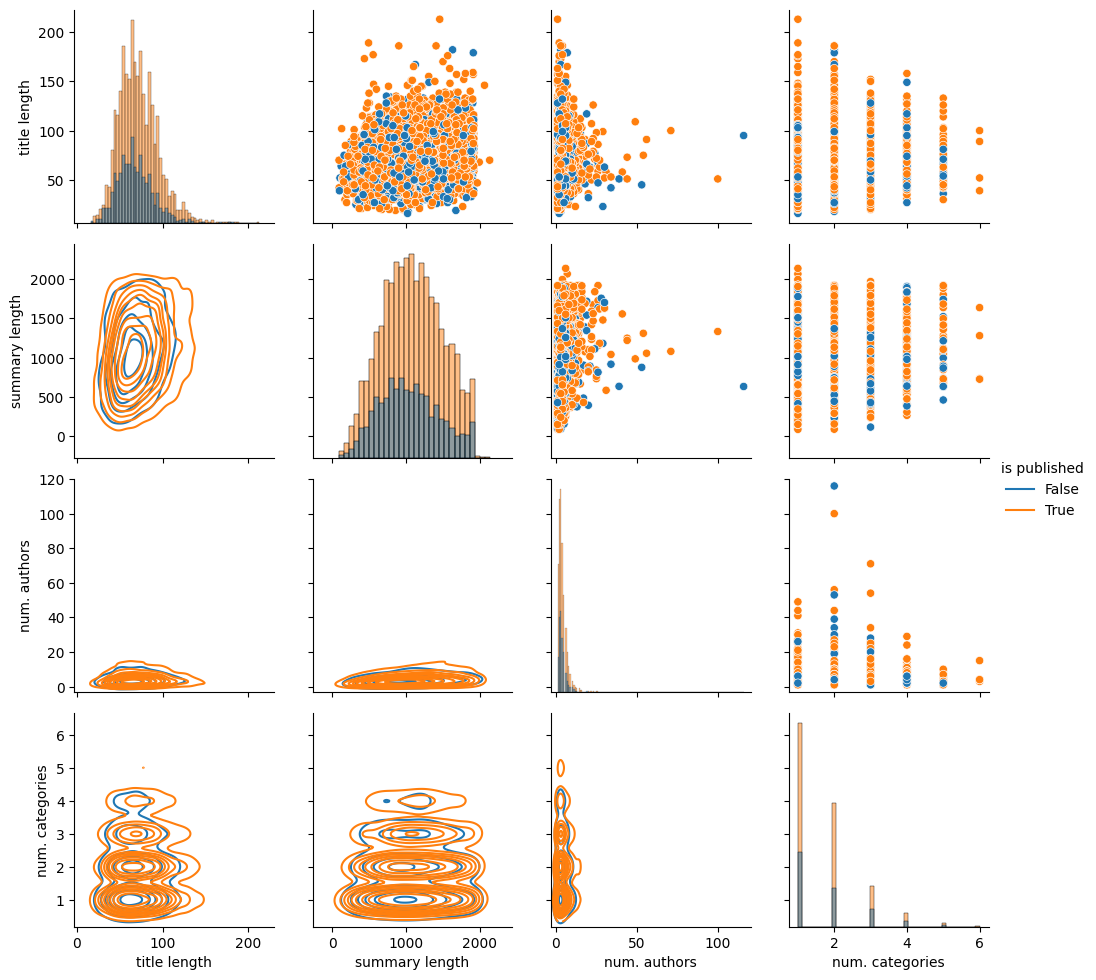

In [33]:
# Lösung

import seaborn as sns

variables = ["title_length", "summary_length", "n_authors", "n_categories"]
g = sns.PairGrid(
    df,
    x_vars=variables,
    y_vars=variables,
    hue="is_published",
    diag_sharey=False,
)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend(title="is published")


def cleanup_label(label: str):
    return (
        label.replace("n_", "num. ").replace("_", " ")
        if isinstance(label, str)
        else label
    )


for ax in g.axes.flat:
    ax.set_xlabel(cleanup_label(ax.get_xlabel()))
    ax.set_ylabel(cleanup_label(ax.get_ylabel()))

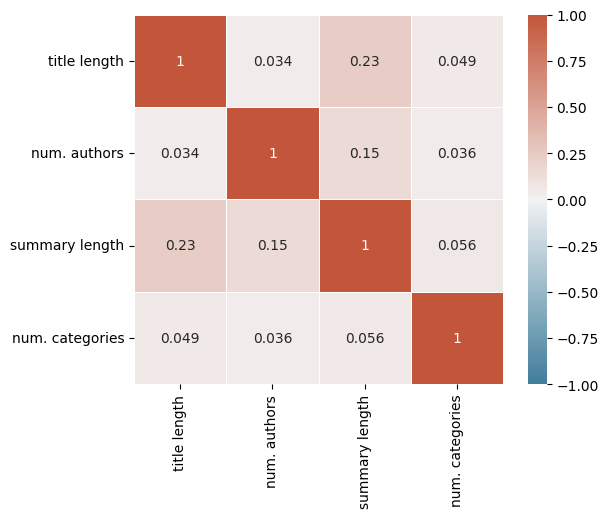

In [34]:
import numpy as np

variables = ["title_length", "n_authors", "summary_length", "n_categories"]
labels = [cleanup_label(v) for v in variables]
corr = df[variables].corr()
h = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    robust=True,
    annot=True,
    linewidths=0.5,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
)

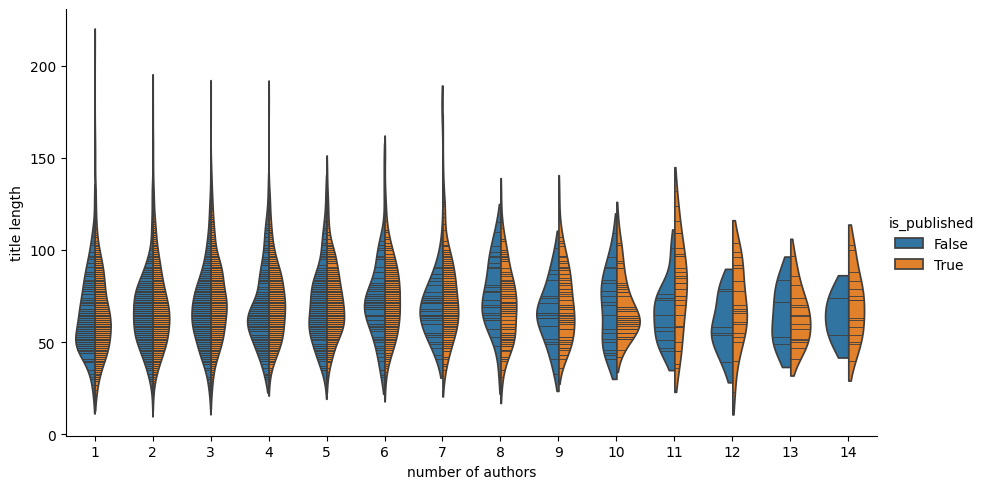

In [35]:
g = sns.catplot(
    df[df["n_authors"] <= 14],
    y="title_length",
    x="n_authors",
    hue="is_published",
    kind="violin",
    split=True,
    cut=1,
    inner="stick",
    aspect=1.8,
)
g.set(xlabel="number of authors", ylabel="title length")

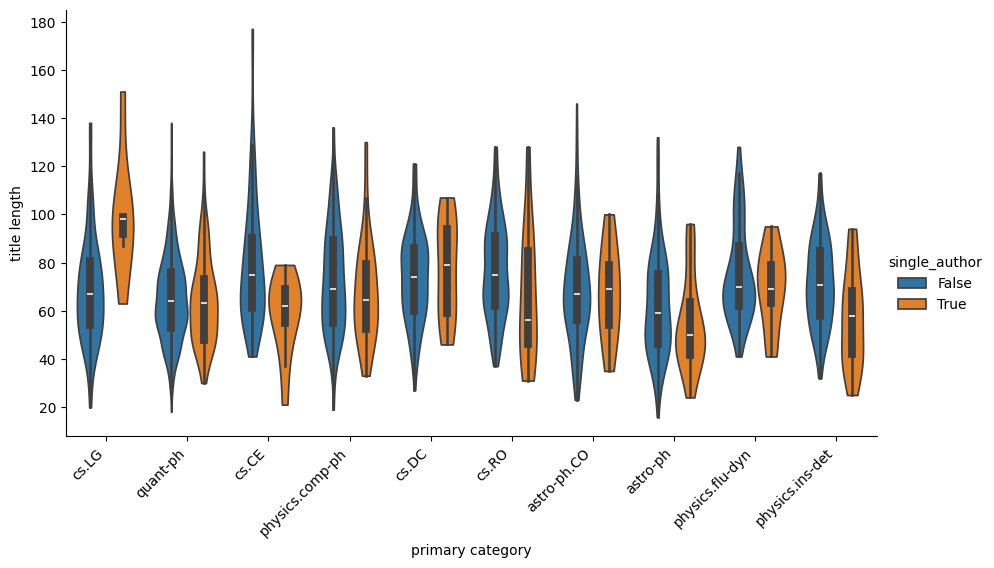

In [36]:
top_categories = set(df_grouped["primary_category"])
df_top = df[df["primary_category"].map(lambda c: c in top_categories)]

g = sns.catplot(
    df_top,
    y="title_length",
    x="primary_category",
    hue="single_author",
    kind="violin",
    cut=0,
    aspect=1.8,
)
g.set(xlabel="primary category", ylabel="title length")
g.set_xticklabels(rotation=45, horizontalalignment="right")